Because of the politics of its' construction,  Route 33 passes through relatively economically disadvantaged areas, and Route 33 disrupted communities in ways that were not positive.

Test the hypothesis that individuals living closer to Rt. 33 are likely to be less wealthy than average for the city.

There might be many ways to do this,   we will try to use data from Open Data Buffalo and geopandas to address the question.  

Here's the idea- find the census blocks that are close (say 300 feet) from the Kensington Expressway (Rt 33).   Then find the average household income for the census blocks close to the 33 from the 2017 census data on open data Buffalo.


a.) Extract the geo data about route 33 from the Roads and Highways data set

b.) Convert it to a CRS based on feet, not lat/long

c.) Add a buffer of 300 feet  around route 33 in the data set.  You may have to increase the buffer size, but we'll see.

d.) Find the boundaries of each census block

e.) Find out which census blocks overlap with your buffer around 33

f.) Plot a map that shows the census blocks,  rt 33 and the buffer around rt 33

g.) Find the median incomes for each census block.    Use an F or t-test to find out if the median income of families in census blocks touching the 33 are statistically significantly different from the median incomes of families in census blocks not touching the 33.     You will need to find a python implementation of an F test or t-test to do this.

In [2]:
import geopandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.wkt import loads


# a.) Extract the geo data about route 33 from the Roads and Highways data set

In [3]:
infile="Highways_and_Roadways.csv"

roads=pd.read_csv(infile)
roads.head()

,the_geom,OBJECTID,NYSStreetID,LeftFromAddress,LeftToAddress,RightFromAddress,RightToAddress,CompleteStreetName,HighwayNumber,Jurisdiction,FCC,ACC,SPEED,LeftPostal,RightPostal,Shape.STLength()
0,MULTILINESTRING ((-78.862643159841 42.93182848...,4760,600058501.0,NaN,NaN,NaN,NaN,Unnamed Street,NaN,14.0,A70,6.0,15.0,14214.0,14214.0,97.321472
1,MULTILINESTRING ((-78.845214165985 42.87086246...,10718,477797294.0,316.0,370.0,317.0,369.0,Smith Street,NaN,12.0,A31,4.0,35.0,14210.0,14210.0,90.442701
2,MULTILINESTRING ((-78.827217182418 42.86574050...,11117,477798597.0,22.0,98.0,23.0,99.0,James P Coppola,NaN,12.0,A30,4.0,35.0,14210.0,14210.0,205.953960
3,MULTILINESTRING ((-78.804619308533 42.86063097...,557,477799268.0,248.0,308.0,NaN,NaN,Mineral Springs Road,NaN,12.0,A35,4.0,35.0,14210.0,14210.0,162.831183
4,MULTILINESTRING ((-78.868159186902 42.94568050...,3403,477776677.0,98.0,98.0,99.0,99.0,Tioga Street,NaN,12.0,A41,5.0,25.0,14216.0,14216.0,4.250600


In [4]:
roads2 = roads

In [5]:
roads.head()

,the_geom,OBJECTID,NYSStreetID,LeftFromAddress,LeftToAddress,RightFromAddress,RightToAddress,CompleteStreetName,HighwayNumber,Jurisdiction,FCC,ACC,SPEED,LeftPostal,RightPostal,Shape.STLength()
0,MULTILINESTRING ((-78.862643159841 42.93182848...,4760,600058501.0,NaN,NaN,NaN,NaN,Unnamed Street,NaN,14.0,A70,6.0,15.0,14214.0,14214.0,97.321472
1,MULTILINESTRING ((-78.845214165985 42.87086246...,10718,477797294.0,316.0,370.0,317.0,369.0,Smith Street,NaN,12.0,A31,4.0,35.0,14210.0,14210.0,90.442701
2,MULTILINESTRING ((-78.827217182418 42.86574050...,11117,477798597.0,22.0,98.0,23.0,99.0,James P Coppola,NaN,12.0,A30,4.0,35.0,14210.0,14210.0,205.953960
3,MULTILINESTRING ((-78.804619308533 42.86063097...,557,477799268.0,248.0,308.0,NaN,NaN,Mineral Springs Road,NaN,12.0,A35,4.0,35.0,14210.0,14210.0,162.831183
4,MULTILINESTRING ((-78.868159186902 42.94568050...,3403,477776677.0,98.0,98.0,99.0,99.0,Tioga Street,NaN,12.0,A41,5.0,25.0,14216.0,14216.0,4.250600


In [6]:
roads2['geometry'] = geopandas.GeoSeries.from_wkt(roads2['the_geom'])

In [7]:
roads2.geometry.name

'geometry'

In [8]:
roads2 = geopandas.GeoDataFrame(roads2, geometry='geometry')

In [9]:
roads2 = roads2.set_crs(epsg = 4326)

In [10]:
roads2.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [11]:
roads2["HighwayNumber"].unique()


array([nan, '16', '954D', '190', '384', '62', '951K', '33', '5', '198',
       '266', '954L', '307', '354', '951J', '130', '265', '550', '955B',
       '950M', '950K', '201', '109', '951L', '315', '189', '952G', '952Q',
       '129'], dtype=object)

There is the beloved 33

In [12]:
roads2.geometry.name

'geometry'

In [13]:
roads2=roads2.drop('the_geom',axis=1)

In [14]:
roads2.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [15]:
roads2.geometry.name

'geometry'

In [16]:
roads2.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

#b.) Convert it to a CRS based on feet, not lat/long

 in feet, with a EPSG of 2263

In [17]:
roads2=roads2.to_crs('EPSG:2263')

roads2.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [18]:
roads3 = roads2.to_crs(epsg=2263)

In [19]:
roads3.crs



<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [20]:
roads3

,OBJECTID,NYSStreetID,LeftFromAddress,LeftToAddress,RightFromAddress,RightToAddress,CompleteStreetName,HighwayNumber,Jurisdiction,FCC,ACC,SPEED,LeftPostal,RightPostal,Shape.STLength(),geometry
0,4760,600058501.0,NaN,NaN,NaN,NaN,Unnamed Street,NaN,14.0,A70,6.0,15.0,14214.0,14214.0,97.321472,"MULTILINESTRING ((-318243.1 1043910.939, -3183..."
1,10718,477797294.0,316.0,370.0,317.0,369.0,Smith Street,NaN,12.0,A31,4.0,35.0,14210.0,14210.0,90.442701,"MULTILINESTRING ((-314808.611 1021451.71, -314..."
2,11117,477798597.0,22.0,98.0,23.0,99.0,James P Coppola,NaN,12.0,A30,4.0,35.0,14210.0,14210.0,205.953960,"MULTILINESTRING ((-310091.189 1019320.199, -31..."
3,557,477799268.0,248.0,308.0,NaN,NaN,Mineral Springs Road,NaN,12.0,A35,4.0,35.0,14210.0,14210.0,162.831183,"MULTILINESTRING ((-304140.176 1017126.463, -30..."
4,3403,477776677.0,98.0,98.0,99.0,99.0,Tioga Street,NaN,12.0,A41,5.0,25.0,14216.0,14216.0,4.250600,"MULTILINESTRING ((-319438.466 1049037.246, -31..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12058,9429,477781542.0,1600.0,1612.0,1601.0,1615.0,Niagara Street,266,1.0,A31,3.0,35.0,14213.0,14213.0,24.186139,"MULTILINESTRING ((-327645.414 1043257.993, -32..."
12059,8131,477789551.0,790.0,810.0,789.0,809.0,Ellicott Street,NaN,12.0,A31,4.0,35.0,14203.0,14203.0,67.144013,"MULTILINESTRING ((-320166.572 1032304.715, -32..."
12060,6190,477788289.0,422.0,446.0,417.0,449.0,Best Street,NaN,12.0,A31,4.0,35.0,14208.0,14211.0,102.251821,"MULTILINESTRING ((-316154.401 1033567.043, -31..."
12061,11209,477798616.0,134.0,198.0,135.0,199.0,Lee Street,NaN,12.0,A41,5.0,25.0,14210.0,14210.0,230.188757,"MULTILINESTRING ((-314115.984 1019519.547, -31..."


#c.) Add a buffer of 300 feet around route 33 in the data set. You may have to increase the buffer size, but we'll see.

In [21]:

#roads2["buffer_33"]=roads2[roads2['HighwayNumber']=="33"].buffer(.003)

the33 = roads2.query('HighwayNumber=="33"')
the33
the33Buffer = the33.buffer(300)

In [22]:
the33Buffer


,0
27,"POLYGON ((-314993.78 1031876.547, -315009.172 ..."
158,"POLYGON ((-313539.516 1040260.354, -313533.275..."
275,"POLYGON ((-313665.982 1039262.85, -313662.914 ..."
292,"POLYGON ((-314551.993 1032344.849, -314570.281..."
460,"POLYGON ((-316249.947 1031807.601, -316191.211..."
...,...
11754,"POLYGON ((-312992.555 1039874.595, -313009.143..."
11854,"POLYGON ((-316058.823 1031923.324, -316032.938..."
11878,"POLYGON ((-320749.301 1030131.729, -320669.184..."
11889,"POLYGON ((-314336.564 1034150.596, -314322.573..."


In [23]:
roads2.dtypes

,0
OBJECTID,int64
NYSStreetID,float64
LeftFromAddress,float64
LeftToAddress,float64
RightFromAddress,float64
RightToAddress,float64
CompleteStreetName,object
HighwayNumber,object
Jurisdiction,float64
FCC,object


#d.) Find the boundaries of each census block

In [24]:
infile2="/content/Census_Tracts_2020.csv"
cencusData=geopandas.read_file(infile2)
cencusData.head()

,STATEFP20,COUNTYFP20,TRACTCE20,GEOID20,NAME20,NAMELSAD20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,the_geom,OBJECTID
0,36,029,004003,36029004003,40.03,Census Tract,G5020,S,890101,0,+42.9354233,-078.8338819,MULTIPOLYGON (((-78.83926514923 42.93133848177...,37
1,36,029,000900,36029000900,9,Census Tract,G5020,S,549188,0,+42.8539069,-078.8165216,MULTIPOLYGON (((-78.823623137997 42.8563174690...,7
2,36,029,003501,36029003501,35.01,Census Tract,G5020,S,680915,0,+42.9088219,-078.8294903,MULTIPOLYGON (((-78.835842145396 42.9037854770...,30
3,36,029,005500,36029005500,55,Census Tract,G5020,S,1559835,0,+42.9388805,-078.8889408,MULTIPOLYGON (((-78.898815168213 42.9364124801...,56
4,36,029,004901,36029004901,49.01,Census Tract,G5020,S,258659,0,+42.9457704,-078.8601229,MULTIPOLYGON (((-78.868149159609 42.9446304824...,48


In [25]:
cencusData["geometry"] = geopandas.GeoSeries.from_wkt(cencusData['the_geom'])

In [26]:
cencusData.geometry

,geometry
0,"MULTIPOLYGON (((-78.83927 42.93134, -78.83926 ..."
1,"MULTIPOLYGON (((-78.82362 42.85632, -78.82353 ..."
2,"MULTIPOLYGON (((-78.83584 42.90379, -78.83584 ..."
3,"MULTIPOLYGON (((-78.89882 42.93641, -78.89846 ..."
4,"MULTIPOLYGON (((-78.86815 42.94463, -78.86798 ..."
...,...
86,"MULTIPOLYGON (((-78.9076 42.94566, -78.90716 4..."
87,"MULTIPOLYGON (((-78.91401 42.94249, -78.90919 ..."
88,"MULTIPOLYGON (((-78.88817 42.91497, -78.88739 ..."
89,"MULTIPOLYGON (((-78.82894 42.90656, -78.8283 4..."


In [27]:
cencusData = geopandas.GeoDataFrame(cencusData, geometry='geometry')

In [28]:
cencusData= cencusData.drop('the_geom',axis=1)

In [29]:
cencusData = cencusData.set_crs(epsg = 4326)

In [30]:
cencusData.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [31]:
cencusData=cencusData.to_crs('EPSG:2263')

cencusData.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [32]:
cencusData.geometry

,geometry
0,"MULTIPOLYGON (((-311997.39 1043385.727, -31198..."
1,"MULTIPOLYGON (((-309317.616 1015835.813, -3092..."
2,"MULTIPOLYGON (((-311635.903 1033301.58, -31162..."
3,"MULTIPOLYGON (((-327828.512 1046120.016, -3277..."
4,"MULTIPOLYGON (((-319457.056 1048654.726, -3194..."
...,...
86,"MULTIPOLYGON (((-329990.085 1049620.048, -3298..."
87,"MULTIPOLYGON (((-331770.057 1048560.142, -3304..."
88,"MULTIPOLYGON (((-325416.994 1038153.901, -3251..."
89,"MULTIPOLYGON (((-309731.626 1034210.386, -3095..."


In [33]:
cencusData.head()

,STATEFP20,COUNTYFP20,TRACTCE20,GEOID20,NAME20,NAMELSAD20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,OBJECTID,geometry
0,36,029,004003,36029004003,40.03,Census Tract,G5020,S,890101,0,+42.9354233,-078.8338819,37,"MULTIPOLYGON (((-311997.39 1043385.727, -31198..."
1,36,029,000900,36029000900,9,Census Tract,G5020,S,549188,0,+42.8539069,-078.8165216,7,"MULTIPOLYGON (((-309317.616 1015835.813, -3092..."
2,36,029,003501,36029003501,35.01,Census Tract,G5020,S,680915,0,+42.9088219,-078.8294903,30,"MULTIPOLYGON (((-311635.903 1033301.58, -31162..."
3,36,029,005500,36029005500,55,Census Tract,G5020,S,1559835,0,+42.9388805,-078.8889408,56,"MULTIPOLYGON (((-327828.512 1046120.016, -3277..."
4,36,029,004901,36029004901,49.01,Census Tract,G5020,S,258659,0,+42.9457704,-078.8601229,48,"MULTIPOLYGON (((-319457.056 1048654.726, -3194..."


In [34]:
cencusData['OBJECTID'].unique()

array(['37', '7', '30', '56', '48', '13', '53', '64', '39', '87', '27',
       '4', '31', '3', '70', '79', '83', '41', '5', '77', '9', '59', '45',
       '20', '38', '18', '62', '33', '90', '78', '81', '86', '63', '50',
       '65', '32', '52', '91', '84', '2', '34', '21', '47', '35', '75',
       '46', '12', '49', '67', '15', '25', '26', '85', '54', '28', '6',
       '23', '76', '36', '69', '80', '40', '88', '60', '55', '10', '72',
       '68', '16', '22', '51', '42', '89', '71', '14', '29', '73', '19',
       '57', '82', '1', '74', '8', '11', '43', '17', '58', '61', '66',
       '24', '44'], dtype=object)

In [35]:
cencusData["boundary"]=cencusData.boundary

<Axes: >

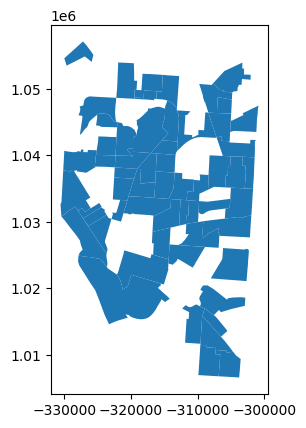

In [36]:
cencusData['geometry'].iloc[1:60].plot()

#e.) Find out which census blocks overlap with your buffer around 33

In [37]:
#cencusData=cencusData.set_crs('EPSG:2263')

cencusData.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [38]:
the33Buffer

,0
27,"POLYGON ((-314993.78 1031876.547, -315009.172 ..."
158,"POLYGON ((-313539.516 1040260.354, -313533.275..."
275,"POLYGON ((-313665.982 1039262.85, -313662.914 ..."
292,"POLYGON ((-314551.993 1032344.849, -314570.281..."
460,"POLYGON ((-316249.947 1031807.601, -316191.211..."
...,...
11754,"POLYGON ((-312992.555 1039874.595, -313009.143..."
11854,"POLYGON ((-316058.823 1031923.324, -316032.938..."
11878,"POLYGON ((-320749.301 1030131.729, -320669.184..."
11889,"POLYGON ((-314336.564 1034150.596, -314322.573..."


In [39]:
buffered33Set = roads2

In [40]:
len(the33Buffer)

171

In [41]:
buffered33Set["geometry"] = the33Buffer

In [42]:
buffered33Set

,OBJECTID,NYSStreetID,LeftFromAddress,LeftToAddress,RightFromAddress,RightToAddress,CompleteStreetName,HighwayNumber,Jurisdiction,FCC,ACC,SPEED,LeftPostal,RightPostal,Shape.STLength(),geometry
0,4760,600058501.0,NaN,NaN,NaN,NaN,Unnamed Street,NaN,14.0,A70,6.0,15.0,14214.0,14214.0,97.321472,None
1,10718,477797294.0,316.0,370.0,317.0,369.0,Smith Street,NaN,12.0,A31,4.0,35.0,14210.0,14210.0,90.442701,None
2,11117,477798597.0,22.0,98.0,23.0,99.0,James P Coppola,NaN,12.0,A30,4.0,35.0,14210.0,14210.0,205.953960,None
3,557,477799268.0,248.0,308.0,NaN,NaN,Mineral Springs Road,NaN,12.0,A35,4.0,35.0,14210.0,14210.0,162.831183,None
4,3403,477776677.0,98.0,98.0,99.0,99.0,Tioga Street,NaN,12.0,A41,5.0,25.0,14216.0,14216.0,4.250600,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12058,9429,477781542.0,1600.0,1612.0,1601.0,1615.0,Niagara Street,266,1.0,A31,3.0,35.0,14213.0,14213.0,24.186139,None
12059,8131,477789551.0,790.0,810.0,789.0,809.0,Ellicott Street,NaN,12.0,A31,4.0,35.0,14203.0,14203.0,67.144013,None
12060,6190,477788289.0,422.0,446.0,417.0,449.0,Best Street,NaN,12.0,A31,4.0,35.0,14208.0,14211.0,102.251821,None
12061,11209,477798616.0,134.0,198.0,135.0,199.0,Lee Street,NaN,12.0,A41,5.0,25.0,14210.0,14210.0,230.188757,None


In [43]:
#ax=roads2.plot( color='k',figsize=(16,16),linewidth=0.25)
#the33Buffer.plot(ax=ax,color='r',edgecolor='black')

#cencusData["boundary"].plot(ax=ax, alpha=.8)


In [44]:
roads2

,OBJECTID,NYSStreetID,LeftFromAddress,LeftToAddress,RightFromAddress,RightToAddress,CompleteStreetName,HighwayNumber,Jurisdiction,FCC,ACC,SPEED,LeftPostal,RightPostal,Shape.STLength(),geometry
0,4760,600058501.0,NaN,NaN,NaN,NaN,Unnamed Street,NaN,14.0,A70,6.0,15.0,14214.0,14214.0,97.321472,None
1,10718,477797294.0,316.0,370.0,317.0,369.0,Smith Street,NaN,12.0,A31,4.0,35.0,14210.0,14210.0,90.442701,None
2,11117,477798597.0,22.0,98.0,23.0,99.0,James P Coppola,NaN,12.0,A30,4.0,35.0,14210.0,14210.0,205.953960,None
3,557,477799268.0,248.0,308.0,NaN,NaN,Mineral Springs Road,NaN,12.0,A35,4.0,35.0,14210.0,14210.0,162.831183,None
4,3403,477776677.0,98.0,98.0,99.0,99.0,Tioga Street,NaN,12.0,A41,5.0,25.0,14216.0,14216.0,4.250600,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12058,9429,477781542.0,1600.0,1612.0,1601.0,1615.0,Niagara Street,266,1.0,A31,3.0,35.0,14213.0,14213.0,24.186139,None
12059,8131,477789551.0,790.0,810.0,789.0,809.0,Ellicott Street,NaN,12.0,A31,4.0,35.0,14203.0,14203.0,67.144013,None
12060,6190,477788289.0,422.0,446.0,417.0,449.0,Best Street,NaN,12.0,A31,4.0,35.0,14208.0,14211.0,102.251821,None
12061,11209,477798616.0,134.0,198.0,135.0,199.0,Lee Street,NaN,12.0,A41,5.0,25.0,14210.0,14210.0,230.188757,None


In [45]:
#mmm well it changes the roads two after i created the buffered33 set wild,

In [46]:
buffered33Set=buffered33Set[buffered33Set['HighwayNumber']=='33']
buffered33Set

,OBJECTID,NYSStreetID,LeftFromAddress,LeftToAddress,RightFromAddress,RightToAddress,CompleteStreetName,HighwayNumber,Jurisdiction,FCC,ACC,SPEED,LeftPostal,RightPostal,Shape.STLength(),geometry
27,6881,477789711.0,NaN,NaN,NaN,NaN,State Route 33,33,1.0,A15,2.0,65.0,14211.0,14211.0,182.116878,"POLYGON ((-314993.78 1031876.547, -315009.172 ..."
158,5670,477783413.0,NaN,NaN,NaN,NaN,State Route 33,33,1.0,A15,2.0,65.0,14214.0,14214.0,31.772200,"POLYGON ((-313539.516 1040260.354, -313533.275..."
275,5700,477784190.0,NaN,NaN,NaN,NaN,State Route 33,33,1.0,A15,2.0,65.0,14214.0,14214.0,19.680589,"POLYGON ((-313665.982 1039262.85, -313662.914 ..."
292,6212,477789175.0,NaN,NaN,NaN,NaN,State Route 33,33,1.0,A15,2.0,65.0,14211.0,14211.0,38.717734,"POLYGON ((-314551.993 1032344.849, -314570.281..."
460,6859,516218529.0,NaN,NaN,NaN,NaN,State Route 33,33,1.0,A15,2.0,65.0,14211.0,14211.0,86.471009,"POLYGON ((-316249.947 1031807.601, -316191.211..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11754,5721,516218747.0,NaN,NaN,NaN,NaN,State Route 33,33,1.0,A15,2.0,65.0,14214.0,14214.0,123.440602,"POLYGON ((-312992.555 1039874.595, -313009.143..."
11854,6861,477789885.0,NaN,NaN,NaN,NaN,State Route 33,33,1.0,A15,2.0,65.0,14211.0,14211.0,47.577214,"POLYGON ((-316058.823 1031923.324, -316032.938..."
11878,8090,477791579.0,54.0,98.0,101.0,101.0,East Tupper Street,33,1.0,A31,3.0,35.0,14203.0,14203.0,112.499472,"POLYGON ((-320749.301 1030131.729, -320669.184..."
11889,6239,477788277.0,NaN,NaN,NaN,NaN,State Route 33,33,1.0,A15,2.0,65.0,14208.0,14211.0,187.706172,"POLYGON ((-314336.564 1034150.596, -314322.573..."


In [47]:
cencusData.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [48]:
cencusData.head()

,STATEFP20,COUNTYFP20,TRACTCE20,GEOID20,NAME20,NAMELSAD20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,OBJECTID,geometry,boundary
0,36,029,004003,36029004003,40.03,Census Tract,G5020,S,890101,0,+42.9354233,-078.8338819,37,"MULTIPOLYGON (((-311997.39 1043385.727, -31198...","MULTILINESTRING ((-311997.39 1043385.727, -311..."
1,36,029,000900,36029000900,9,Census Tract,G5020,S,549188,0,+42.8539069,-078.8165216,7,"MULTIPOLYGON (((-309317.616 1015835.813, -3092...","MULTILINESTRING ((-309317.616 1015835.813, -30..."
2,36,029,003501,36029003501,35.01,Census Tract,G5020,S,680915,0,+42.9088219,-078.8294903,30,"MULTIPOLYGON (((-311635.903 1033301.58, -31162...","MULTILINESTRING ((-311635.903 1033301.58, -311..."
3,36,029,005500,36029005500,55,Census Tract,G5020,S,1559835,0,+42.9388805,-078.8889408,56,"MULTIPOLYGON (((-327828.512 1046120.016, -3277...","MULTILINESTRING ((-327828.512 1046120.016, -32..."
4,36,029,004901,36029004901,49.01,Census Tract,G5020,S,258659,0,+42.9457704,-078.8601229,48,"MULTIPOLYGON (((-319457.056 1048654.726, -3194...","MULTILINESTRING ((-319457.056 1048654.726, -31..."


In [49]:
cencusData2 = cencusData
cencusData2 = cencusData2.drop('geometry',axis=1)
cencusData2['geometry'] = cencusData2['boundary']

In [50]:
#block33 = geopandas.sjoin(cencusData2, buffered33Set,  how='inner', op='intersects')
block33 = geopandas.sjoin(cencusData2, buffered33Set, how='inner', predicate='intersects')

In [51]:
block33.dtypes

,0
STATEFP20,object
COUNTYFP20,object
TRACTCE20,object
GEOID20,object
NAME20,object
NAMELSAD20,object
MTFCC20,object
FUNCSTAT20,object
ALAND20,object
AWATER20,object


In [52]:
block33['RightPostal'].unique()

array([14214., 14215., 14211., 14208., 14204., 14203.])

In [53]:
roads2['RightPostal'].unique()

array([14214., 14210., 14216., 14202., 14207., 14203., 14220., 14204.,
       14208., 14213., 14226., 14218.,    nan, 14211., 14215., 14206.,
       14212., 14209., 14222., 14201., 14223., 14217., 14225., 14224.])

In [54]:
touchingBlocks= block33['boundary'].drop_duplicates()

In [55]:
len(touchingBlocks)

17

<Axes: >

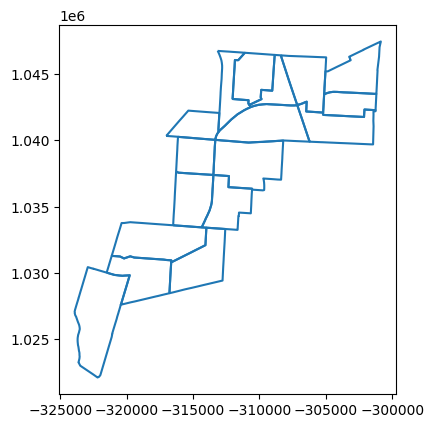

In [56]:
touchingBlocks.plot()

<Axes: >

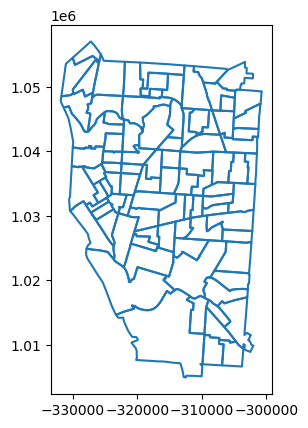

In [57]:
cencusData["boundary"].plot()

In [58]:
len(cencusData["boundary"])

91

# There it is. The answer

#f.) Plot a map that shows the census blocks, rt 33 and the buffer around rt 33

<Axes: >

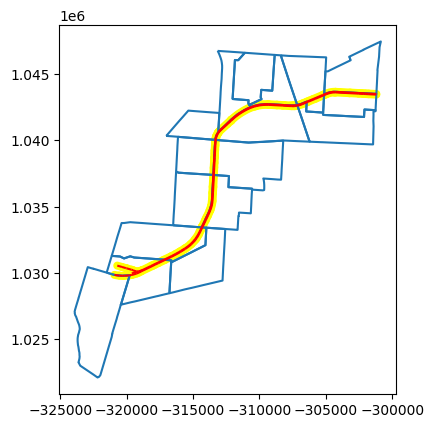

In [59]:
#ax = block33['boundary'].plot()
ax = touchingBlocks.plot()
buffered33Set["geometry"].plot(ax=ax,color = "yellow")
the33.plot(ax=ax,color = "red")

###g.) Find the median incomes for each census block. Use an F or t-test to find out if the median income of families in census blocks touching the 33 are statistically significantly different from the median incomes of families in census blocks not touching the 33. You will need to find a python implementation of an F test or t-test to do this

To find the median income I am going to need the census data as well as the income data.

In [60]:
list(cencusData["boundary"].index)
touchingBlocks.index
theKey=np.isin(list(cencusData["boundary"].index),touchingBlocks.index)
notTouch33= cencusData["boundary"].iloc[~theKey]
#len(notTouch33)
notTouch33
touchingBlocks
len(touchingBlocks)+len(notTouch33)

91

In [61]:
cencusData

,STATEFP20,COUNTYFP20,TRACTCE20,GEOID20,NAME20,NAMELSAD20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,OBJECTID,geometry,boundary
0,36,029,004003,36029004003,40.03,Census Tract,G5020,S,890101,0,+42.9354233,-078.8338819,37,"MULTIPOLYGON (((-311997.39 1043385.727, -31198...","MULTILINESTRING ((-311997.39 1043385.727, -311..."
1,36,029,000900,36029000900,9,Census Tract,G5020,S,549188,0,+42.8539069,-078.8165216,7,"MULTIPOLYGON (((-309317.616 1015835.813, -3092...","MULTILINESTRING ((-309317.616 1015835.813, -30..."
2,36,029,003501,36029003501,35.01,Census Tract,G5020,S,680915,0,+42.9088219,-078.8294903,30,"MULTIPOLYGON (((-311635.903 1033301.58, -31162...","MULTILINESTRING ((-311635.903 1033301.58, -311..."
3,36,029,005500,36029005500,55,Census Tract,G5020,S,1559835,0,+42.9388805,-078.8889408,56,"MULTIPOLYGON (((-327828.512 1046120.016, -3277...","MULTILINESTRING ((-327828.512 1046120.016, -32..."
4,36,029,004901,36029004901,49.01,Census Tract,G5020,S,258659,0,+42.9457704,-078.8601229,48,"MULTIPOLYGON (((-319457.056 1048654.726, -3194...","MULTILINESTRING ((-319457.056 1048654.726, -31..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,36,029,005700,36029005700,57,Census Tract,G5020,S,956845,0,+42.9497231,-078.8992508,58,"MULTIPOLYGON (((-329990.085 1049620.048, -3298...","MULTILINESTRING ((-329990.085 1049620.048, -32..."
87,36,029,005900,36029005900,59,Census Tract,G5020,S,1217883,297447,+42.9373135,-078.9031215,61,"MULTIPOLYGON (((-331770.057 1048560.142, -3304...","MULTILINESTRING ((-331770.057 1048560.142, -33..."
88,36,029,006601,36029006601,66.01,Census Tract,G5020,S,392015,0,+42.9134654,-078.8822804,66,"MULTIPOLYGON (((-325416.994 1038153.901, -3251...","MULTILINESTRING ((-325416.994 1038153.901, -32..."
89,36,029,002900,36029002900,29,Census Tract,G5020,S,777409,0,+42.9066274,-078.8198651,24,"MULTIPOLYGON (((-309731.626 1034210.386, -3095...","MULTILINESTRING ((-309731.626 1034210.386, -30..."


In [62]:
#Import the income data
infile3="/content/ACS_2017_Data_Profile_5_Year_Estimates__Erie_County_-_Census_Tract_20240401.csv"

dataProf=geopandas.read_file(infile3)


In [63]:
dataProf['geometry'] = geopandas.GeoSeries.from_wkt(dataProf['Location'])

In [64]:
dataProf = geopandas.GeoDataFrame(dataProf, geometry='geometry')

In [65]:
dataProf.crs

In [66]:
dataProf = dataProf.set_crs(epsg = 4326)

In [67]:
dataProf

,GEO.display.label.Geography,GEO.id2.Id2,HC01_VC03.Estimate..HOUSEHOLDS.BY.TYPE...Total.households,HC01_VC04.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families.,HC01_VC05.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....With.own.children.of.the.householder.under.18.years,HC01_VC06.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....Married.couple.family,HC01_VC07.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....Married.couple.family...With.own.children.of.the.householder.under.18.years,HC01_VC08.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....Male.householder..no.wife.present..family,HC01_VC09.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....Male.householder..no.wife.present..family...With.own.children.of.the.householder.under.18.years,HC01_VC10.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....Female.householder..no.husband.present..family,...,HC01_VC104.Estimate..HISPANIC.OR.LATINO.AND.RACE...Total.population...Not.Hispanic.or.Latino...Some.other.race.alone,HC01_VC105.Estimate..HISPANIC.OR.LATINO.AND.RACE...Total.population...Not.Hispanic.or.Latino...Two.or.more.races,HC01_VC106.Estimate..HISPANIC.OR.LATINO.AND.RACE...Total.population...Not.Hispanic.or.Latino...Two.or.more.races...Two.races.including.Some.other.race,HC01_VC107.Estimate..HISPANIC.OR.LATINO.AND.RACE...Total.population...Not.Hispanic.or.Latino...Two.or.more.races...Two.races.excluding.Some.other.race..and.Three.or.more.races,HC01_VC109.Estimate..HISPANIC.OR.LATINO.AND.RACE...Total.housing.units,HC01_VC113.Estimate..CITIZEN..VOTING.AGE.POPULATION...Citizen..18.and.over.population,HC01_VC114.Estimate..CITIZEN..VOTING.AGE.POPULATION...Citizen..18.and.over.population...Male,HC01_VC115.Estimate..CITIZEN..VOTING.AGE.POPULATION...Citizen..18.and.over.population...Female,Location,geometry
0,"Census Tract 9900, Erie County, New York",36029990000,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,POINT (-78.86383129022715 42.83370964619451),POINT (-78.86383 42.83371)
1,"Census Tract 72.02, Erie County, New York",36029007202,968,455,212,219,55,41,25,195,...,18,5,0,5,1048,1425,692,733,POINT (-78.89200971828663 42.888934),POINT (-78.89201 42.88893)
2,"Census Tract 108.05, Erie County, New York",36029010805,2144,1266,386,1041,305,101,52,124,...,0,53,0,53,2144,4085,2055,2030,POINT (-78.70926668450177 42.8726015),POINT (-78.70927 42.8726)
3,"Census Tract 91.04, Erie County, New York",36029009104,1704,1251,506,1054,435,102,45,95,...,16,84,0,84,1719,3284,1557,1727,POINT (-78.75412065894162 42.9853335),POINT (-78.75412 42.98533)
4,"Census Tract 9400, Erie County, New York",36029940000,785,460,185,202,43,64,30,194,...,28,133,0,133,926,1402,606,796,POINT (-78.96774988447652 42.5279365),POINT (-78.96775 42.52794)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,"Census Tract 80.03, Erie County, New York",36029008003,2196,1220,383,879,232,178,57,163,...,0,104,14,90,2333,3990,1788,2202,POINT (-78.83175526013395 42.9636025),POINT (-78.83176 42.9636)
233,"Census Tract 157, Erie County, New York",36029015700,1293,927,330,761,290,54,13,112,...,0,35,0,35,1373,2584,1298,1286,POINT (-78.86355308731274 42.5703995),POINT (-78.86355 42.5704)
234,"Census Tract 165, Erie County, New York",36029016500,711,241,56,129,0,5,0,107,...,0,32,0,32,926,1486,913,573,POINT (-78.8740711109348 42.8831645),POINT (-78.87407 42.88316)
235,"Census Tract 175.01, Erie County, New York",36029017501,677,379,173,202,61,43,19,134,...,4,105,0,105,718,1138,478,660,POINT (-78.92004894094771 42.4794565),POINT (-78.92005 42.47946)


In [68]:
dataProf = dataProf.to_crs('EPSG:2263')
cencusData2 = cencusData2.to_crs('EPSG:2263')

<Axes: >

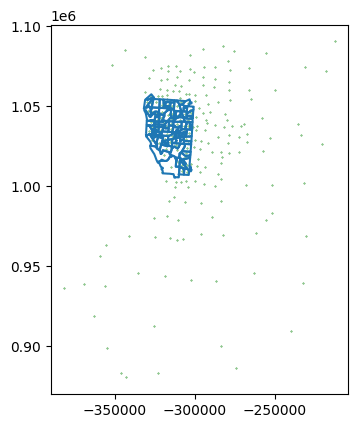

In [69]:
ax=cencusData['boundary'].plot()
dataProf['geometry'].plot(ax=ax, color="green",markersize =.1)

In [70]:
dataProf['geometry'].intersects(cencusData2['geometry']).unique()

/tmp/ipython-input-2113919080.py:1: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  dataProf['geometry'].intersects(cencusData2['geometry']).unique()


array([False])

In [71]:
cencusData2

,STATEFP20,COUNTYFP20,TRACTCE20,GEOID20,NAME20,NAMELSAD20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,OBJECTID,boundary,geometry
0,36,029,004003,36029004003,40.03,Census Tract,G5020,S,890101,0,+42.9354233,-078.8338819,37,"MULTILINESTRING ((-311997.39 1043385.727, -311...","MULTILINESTRING ((-311997.39 1043385.727, -311..."
1,36,029,000900,36029000900,9,Census Tract,G5020,S,549188,0,+42.8539069,-078.8165216,7,"MULTILINESTRING ((-309317.616 1015835.813, -30...","MULTILINESTRING ((-309317.616 1015835.813, -30..."
2,36,029,003501,36029003501,35.01,Census Tract,G5020,S,680915,0,+42.9088219,-078.8294903,30,"MULTILINESTRING ((-311635.903 1033301.58, -311...","MULTILINESTRING ((-311635.903 1033301.58, -311..."
3,36,029,005500,36029005500,55,Census Tract,G5020,S,1559835,0,+42.9388805,-078.8889408,56,"MULTILINESTRING ((-327828.512 1046120.016, -32...","MULTILINESTRING ((-327828.512 1046120.016, -32..."
4,36,029,004901,36029004901,49.01,Census Tract,G5020,S,258659,0,+42.9457704,-078.8601229,48,"MULTILINESTRING ((-319457.056 1048654.726, -31...","MULTILINESTRING ((-319457.056 1048654.726, -31..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,36,029,005700,36029005700,57,Census Tract,G5020,S,956845,0,+42.9497231,-078.8992508,58,"MULTILINESTRING ((-329990.085 1049620.048, -32...","MULTILINESTRING ((-329990.085 1049620.048, -32..."
87,36,029,005900,36029005900,59,Census Tract,G5020,S,1217883,297447,+42.9373135,-078.9031215,61,"MULTILINESTRING ((-331770.057 1048560.142, -33...","MULTILINESTRING ((-331770.057 1048560.142, -33..."
88,36,029,006601,36029006601,66.01,Census Tract,G5020,S,392015,0,+42.9134654,-078.8822804,66,"MULTILINESTRING ((-325416.994 1038153.901, -32...","MULTILINESTRING ((-325416.994 1038153.901, -32..."
89,36,029,002900,36029002900,29,Census Tract,G5020,S,777409,0,+42.9066274,-078.8198651,24,"MULTILINESTRING ((-309731.626 1034210.386, -30...","MULTILINESTRING ((-309731.626 1034210.386, -30..."


In [72]:
#buffaloProfData = geopandas.sjoin(dataProf, cencusData, op='intersects')
buffaloProfData = geopandas.sjoin(dataProf, cencusData, predicate='intersects')

buffaloProfData.head()


,GEO.display.label.Geography,GEO.id2.Id2,HC01_VC03.Estimate..HOUSEHOLDS.BY.TYPE...Total.households,HC01_VC04.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families.,HC01_VC05.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....With.own.children.of.the.householder.under.18.years,HC01_VC06.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....Married.couple.family,HC01_VC07.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....Married.couple.family...With.own.children.of.the.householder.under.18.years,HC01_VC08.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....Male.householder..no.wife.present..family,HC01_VC09.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....Male.householder..no.wife.present..family...With.own.children.of.the.householder.under.18.years,HC01_VC10.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....Female.householder..no.husband.present..family,...,NAME20,NAMELSAD20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,OBJECTID,boundary
1,"Census Tract 72.02, Erie County, New York",36029007202,968,455,212,219,55,41,25,195,...,72.02,Census Tract,G5020,S,1024153,999315,+42.8915687,-078.8943415,79,"MULTILINESTRING ((-330236.923 1030919.381, -33..."
5,"Census Tract 1.10, Erie County, New York",36029000110,1003,717,293,446,203,112,40,159,...,1.10,Census Tract,G5020,S,8373929,1313301,+42.8474559,-078.8466675,1,"MULTILINESTRING ((-323294.088 1014643.126, -32..."
10,"Census Tract 8, Erie County, New York",36029000800,1885,1160,469,633,283,154,17,373,...,8,Census Tract,G5020,S,1090392,0,+42.8476264,-078.8171281,6,"MULTILINESTRING ((-309574.477 1011707.388, -30..."
13,"Census Tract 15, Erie County, New York",36029001500,662,325,153,96,0,31,20,198,...,15,Census Tract,G5020,S,956234,0,+42.8854677,-078.8484884,12,"MULTILINESTRING ((-316771.643 1028475.919, -31..."
14,"Census Tract 63.01, Erie County, New York",36029006301,2157,1074,516,695,256,135,88,244,...,63.01,Census Tract,G5020,S,723107,0,+42.9240064,-078.8822363,63,"MULTILINESTRING ((-325141.276 1040734.892, -32..."


Find the median incomes for each census block

Lets do it with ObjectID.

In [73]:
buffaloProfData['HC01_VC114.Estimate..INCOME.AND.BENEFITS..IN.2017.INFLATION.ADJUSTED.DOLLARS....Families...Median.family.income..dollars.'] = pd.to_numeric(
    buffaloProfData['HC01_VC114.Estimate..INCOME.AND.BENEFITS..IN.2017.INFLATION.ADJUSTED.DOLLARS....Families...Median.family.income..dollars.'],
    errors='coerce'
)


In [74]:
median_income_by_objectid = buffaloProfData.groupby('OBJECTID')['HC01_VC114.Estimate..INCOME.AND.BENEFITS..IN.2017.INFLATION.ADJUSTED.DOLLARS....Families...Median.family.income..dollars.'].median()

In [75]:
median_income_by_objectid.index

Index(['1', '10', '12', '13', '15', '16', '17', '18', '19', '2', '21', '23',
       '24', '25', '26', '27', '28', '29', '3', '31', '32', '33', '34', '35',
       '37', '38', '39', '4', '40', '41', '42', '43', '44', '46', '47', '49',
       '5', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '6',
       '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '7', '71',
       '72', '74', '75', '76', '78', '79', '8', '80', '81', '82', '83', '84',
       '86', '87', '88', '89', '9', '90', '91'],
      dtype='object', name='OBJECTID')

Use an F or t-test to find out if the median income of families in census blocks touching the 33 are statistically significantly different from the median incomes of families in census blocks not touching the 33.

Lets first get the the 2 census sets 1 thats touching the 33 and ones that are not

In [76]:
theKey

array([ True, False, False, False, False, False,  True, False,  True,
       False,  True, False,  True, False, False, False,  True,  True,
       False, False, False, False, False, False,  True, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False,  True, False, False,
        True, False, False, False,  True, False, False, False,  True,
       False, False, False, False, False, False, False, False,  True,
       False, False, False,  True, False,  True, False,  True, False,
       False, False, False, False, False, False, False, False, False,
       False])

In [77]:
touchingData = cencusData[theKey]
len(touchingData)

17

In [78]:
notTouchingData = cencusData[~theKey]
notTouchingData

,STATEFP20,COUNTYFP20,TRACTCE20,GEOID20,NAME20,NAMELSAD20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,OBJECTID,geometry,boundary
1,36,029,000900,36029000900,9,Census Tract,G5020,S,549188,0,+42.8539069,-078.8165216,7,"MULTIPOLYGON (((-309317.616 1015835.813, -3092...","MULTILINESTRING ((-309317.616 1015835.813, -30..."
2,36,029,003501,36029003501,35.01,Census Tract,G5020,S,680915,0,+42.9088219,-078.8294903,30,"MULTIPOLYGON (((-311635.903 1033301.58, -31162...","MULTILINESTRING ((-311635.903 1033301.58, -311..."
3,36,029,005500,36029005500,55,Census Tract,G5020,S,1559835,0,+42.9388805,-078.8889408,56,"MULTIPOLYGON (((-327828.512 1046120.016, -3277...","MULTILINESTRING ((-327828.512 1046120.016, -32..."
4,36,029,004901,36029004901,49.01,Census Tract,G5020,S,258659,0,+42.9457704,-078.8601229,48,"MULTIPOLYGON (((-319457.056 1048654.726, -3194...","MULTILINESTRING ((-319457.056 1048654.726, -31..."
5,36,029,001601,36029001601,16.01,Census Tract,G5020,S,1362133,0,+42.8889822,-078.8269589,13,"MULTIPOLYGON (((-312923.228 1026517.569, -3126...","MULTILINESTRING ((-312923.228 1026517.569, -31..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,36,029,005700,36029005700,57,Census Tract,G5020,S,956845,0,+42.9497231,-078.8992508,58,"MULTIPOLYGON (((-329990.085 1049620.048, -3298...","MULTILINESTRING ((-329990.085 1049620.048, -32..."
87,36,029,005900,36029005900,59,Census Tract,G5020,S,1217883,297447,+42.9373135,-078.9031215,61,"MULTIPOLYGON (((-331770.057 1048560.142, -3304...","MULTILINESTRING ((-331770.057 1048560.142, -33..."
88,36,029,006601,36029006601,66.01,Census Tract,G5020,S,392015,0,+42.9134654,-078.8822804,66,"MULTIPOLYGON (((-325416.994 1038153.901, -3251...","MULTILINESTRING ((-325416.994 1038153.901, -32..."
89,36,029,002900,36029002900,29,Census Tract,G5020,S,777409,0,+42.9066274,-078.8198651,24,"MULTIPOLYGON (((-309731.626 1034210.386, -3095...","MULTILINESTRING ((-309731.626 1034210.386, -30..."


Lets join the income data and census data

In [79]:
#nearHighway = geopandas.sjoin(dataProf, touchingData, op='intersects')
nearHighway = geopandas.sjoin(dataProf, touchingData, predicate='intersects')

In [80]:
#awayFromWay = geopandas.sjoin(dataProf, notTouchingData, op='intersects')
awayFromWay = geopandas.sjoin(dataProf, notTouchingData, predicate='intersects')

In [81]:
awayIncome = awayFromWay['HC01_VC114.Estimate..INCOME.AND.BENEFITS..IN.2017.INFLATION.ADJUSTED.DOLLARS....Families...Median.family.income..dollars.']

In [82]:
awayIncome

,HC01_VC114.Estimate..INCOME.AND.BENEFITS..IN.2017.INFLATION.ADJUSTED.DOLLARS....Families...Median.family.income..dollars.
1,43750
5,45745
10,71111
13,29225
14,59487
...,...
214,85330
221,101713
222,30618
225,19743


In [83]:
closeIncome = nearHighway['HC01_VC114.Estimate..INCOME.AND.BENEFITS..IN.2017.INFLATION.ADJUSTED.DOLLARS....Families...Median.family.income..dollars.']

In [84]:
import scipy.stats as stats

In [85]:
import seaborn as sns

In [86]:
closeIncome

,HC01_VC114.Estimate..INCOME.AND.BENEFITS..IN.2017.INFLATION.ADJUSTED.DOLLARS....Families...Median.family.income..dollars.
20,31027
22,32581
38,29632
69,33571
103,41514
104,42059
106,43056
114,25982
148,32287
154,15951


In [87]:
closeIncome = pd.to_numeric(closeIncome, errors='coerce')
closeIncome = closeIncome.dropna()

In [88]:
print(closeIncome.describe())

count       16.000000
mean     36993.812500
std      15814.950396
min      15951.000000
25%      29586.250000
50%      33076.000000
75%      41650.250000
max      89485.000000
Name: HC01_VC114.Estimate..INCOME.AND.BENEFITS..IN.2017.INFLATION.ADJUSTED.DOLLARS....Families...Median.family.income..dollars., dtype: float64


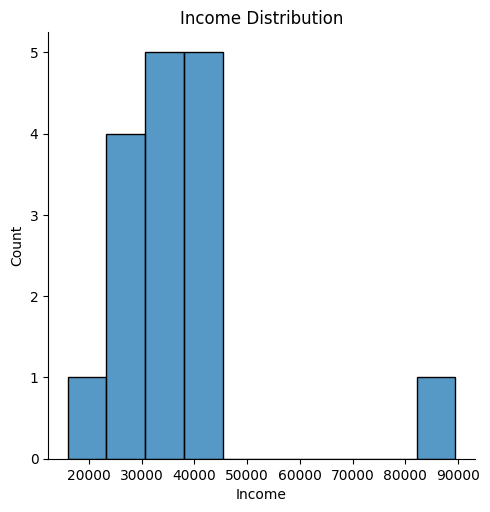

In [89]:
sns.displot(closeIncome, kde=False, bins = 10)
plt.xlabel('Income')
plt.ylabel('Count')
plt.title('Income Distribution')
plt.show()

In [90]:
awayIncome = pd.to_numeric(awayIncome, errors='coerce')

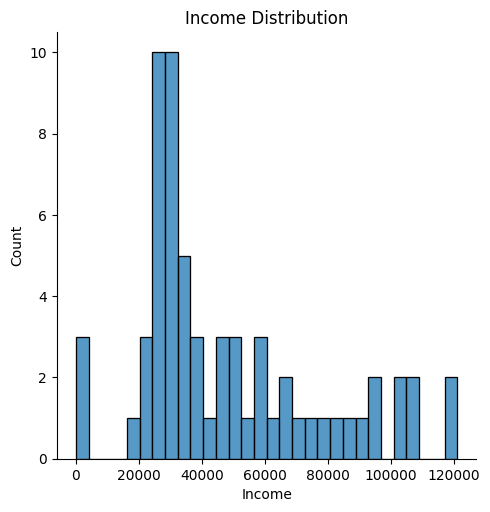

In [91]:
sns.displot(awayIncome, bins = 30)
plt.xlabel('Income')
plt.ylabel('Count')
plt.title('Income Distribution')
plt.show()

# From this histogram we can see that the high median income census blocks for the most part are located away from the NY-33


### I am not going to do a t-test as the graphs aren't normally distributed, I am also not going to use the F-test because I want to know if the typical income of one group is diffrent from the other not the contruction of one distribution is diffrent from the other.

# I am going with Mann-Whitney U Test to determine if there is a diffrence in the typical incomes of the two groups. It is a non-parametric test.

In [92]:
from scipy.stats import mannwhitneyu

In [93]:
U1, p = mannwhitneyu(awayIncome, closeIncome, method="exact")

In [94]:
print(U1)

567.0


In [95]:
nx, ny = len(awayIncome), len(closeIncome)
U2 = nx*ny - U1

In [96]:
print(U2)

441.0


In [97]:
print(p)

0.449483029288418


### So based on this at a = 0.01 we this P-value isn't statistically significant and we can say that there isn't a diffrence in the typical median income of the census blocks touching the NY-33 and those not touching it. But again I saw on the histogram that most of the high income medians were not touched by the highway.

### Now lets try to see what the p-value is when we try to determine whether or not one group's typical income is greater than the other.


H0 : n1=n2  


H1 : n1 < n2


In [99]:
u_stat, p_greater = mannwhitneyu(closeIncome, awayIncome, alternative='less')

In [100]:
p_greater

np.float64(0.22289857342594604)

H0 : n1=n2  


H1 : n1 > n2


In [103]:
u_stat, p_less = mannwhitneyu(closeIncome, awayIncome, alternative='greater')

In [104]:
p_less

np.float64(0.7807236569279873)


###Neither are statistically significant at a=.05, For the test to see if awayIncome is greater than closeIncome we get a p-value of .22 and to see if closeIncome is greater we get a p-value of 0.78. With a p value of .22 there is a chance of there being purposeful steps taken to build the NY-33 through the poorer areas. However this should not me taken in a negative light as this likely increases the economic activites in these poorer areas.